# Khám Phá Dữ Liệu Chuyên Sâu (Exploratory Data Analysis - EDA)

Notebook này thực hiện các bước khám phá dữ liệu chuẩn mực đối với ảnh MRI khối u não, bao gồm:
1. **Phân tích phân bố các nhãn (Class Distribution)**.
2. **Phân tích kích thước ảnh (Image Size Distribution)**.
3. **Trực quan hóa ảnh mẫu (Sample Images Visualization)**.
4. **Phân tích phổ cường độ Pixel (Pixel Intensity Histograms)**.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')

# Thiết lập giao diện biểu đồ
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Đường dẫn thư mục dữ liệu
DATA_DIR = '../data/Training'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Kiểm tra dữ liệu
if not os.path.exists(DATA_DIR):
    print(f"CẢNH BÁO: Không tìm thấy thư mục {DATA_DIR}. Vui lòng giải nén dữ liệu.")
else:
    print(f"Dữ liệu sẽ được load từ: {DATA_DIR}")

Dữ liệu sẽ được load từ: ../data/Training


## 1. Phân bố các nhãn (Class Distribution)

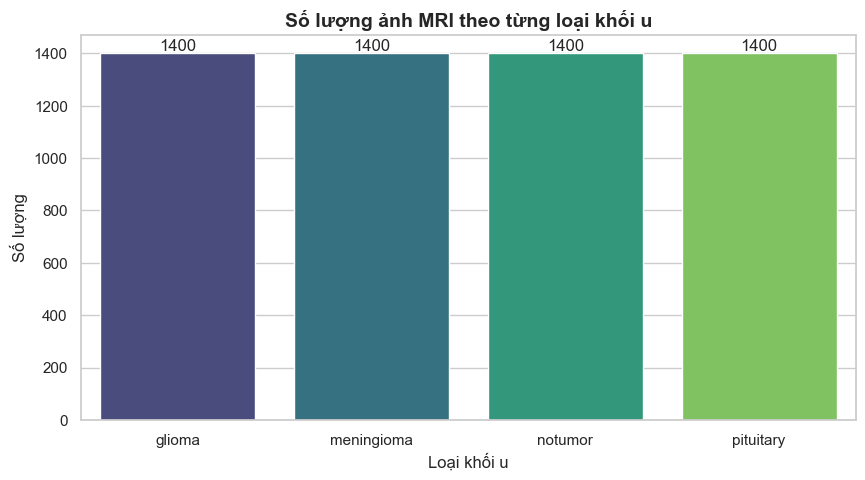

In [3]:
class_counts = {}
image_paths = []
labels = []

for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    if os.path.exists(cls_dir):
        imgs = [os.path.join(cls_dir, img) for img in os.listdir(cls_dir) if img.endswith(('.jpg', '.png', '.jpeg'))]
        class_counts[cls] = len(imgs)
        image_paths.extend(imgs)
        labels.extend([cls] * len(imgs))
    else:
        class_counts[cls] = 0

df = pd.DataFrame({'Path': image_paths, 'Label': labels})

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.title('Số lượng ảnh MRI theo từng loại khối u', fontsize=14, fontweight='bold')
plt.xlabel('Loại khối u')
plt.ylabel('Số lượng')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

## 2. Kích thước hình ảnh (Image Dimensions)
Việc hiểu kích thước ảnh (rộng x cao) giúp thiết lập thông số `Resize` chuẩn xác trong quá trình Data Preparation.

Đang đọc kích thước ảnh:   0%|          | 0/500 [00:00<?, ?it/s]

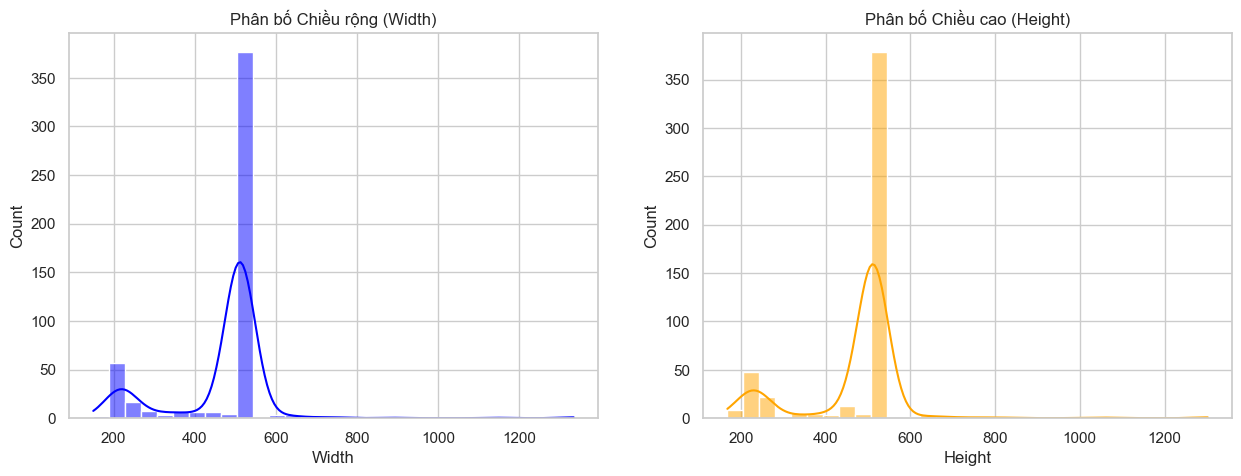

In [4]:
widths = []
heights = []

# Lấy ngẫu nhiên 500 ảnh để phân tích kích thước tránh quá tải bộ nhớ
sample_df = df.sample(n=min(500, len(df)), random_state=42) if len(df) > 0 else df

for path in tqdm(sample_df['Path'], desc="Đang đọc kích thước ảnh"):
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        pass

sample_df['Width'] = widths
sample_df['Height'] = heights

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(sample_df['Width'], kde=True, ax=axes[0], color='blue', bins=30)
axes[0].set_title('Phân bố Chiều rộng (Width)')

sns.histplot(sample_df['Height'], kde=True, ax=axes[1], color='orange', bins=30)
axes[1].set_title('Phân bố Chiều cao (Height)')

plt.show()

## 3. Trực quan hóa ảnh mẫu (Sample Images)
Kiểm tra bằng mắt thường (Sanity check) xem các khối u hiển thị như thế nào trên ảnh X-quang/MRI.

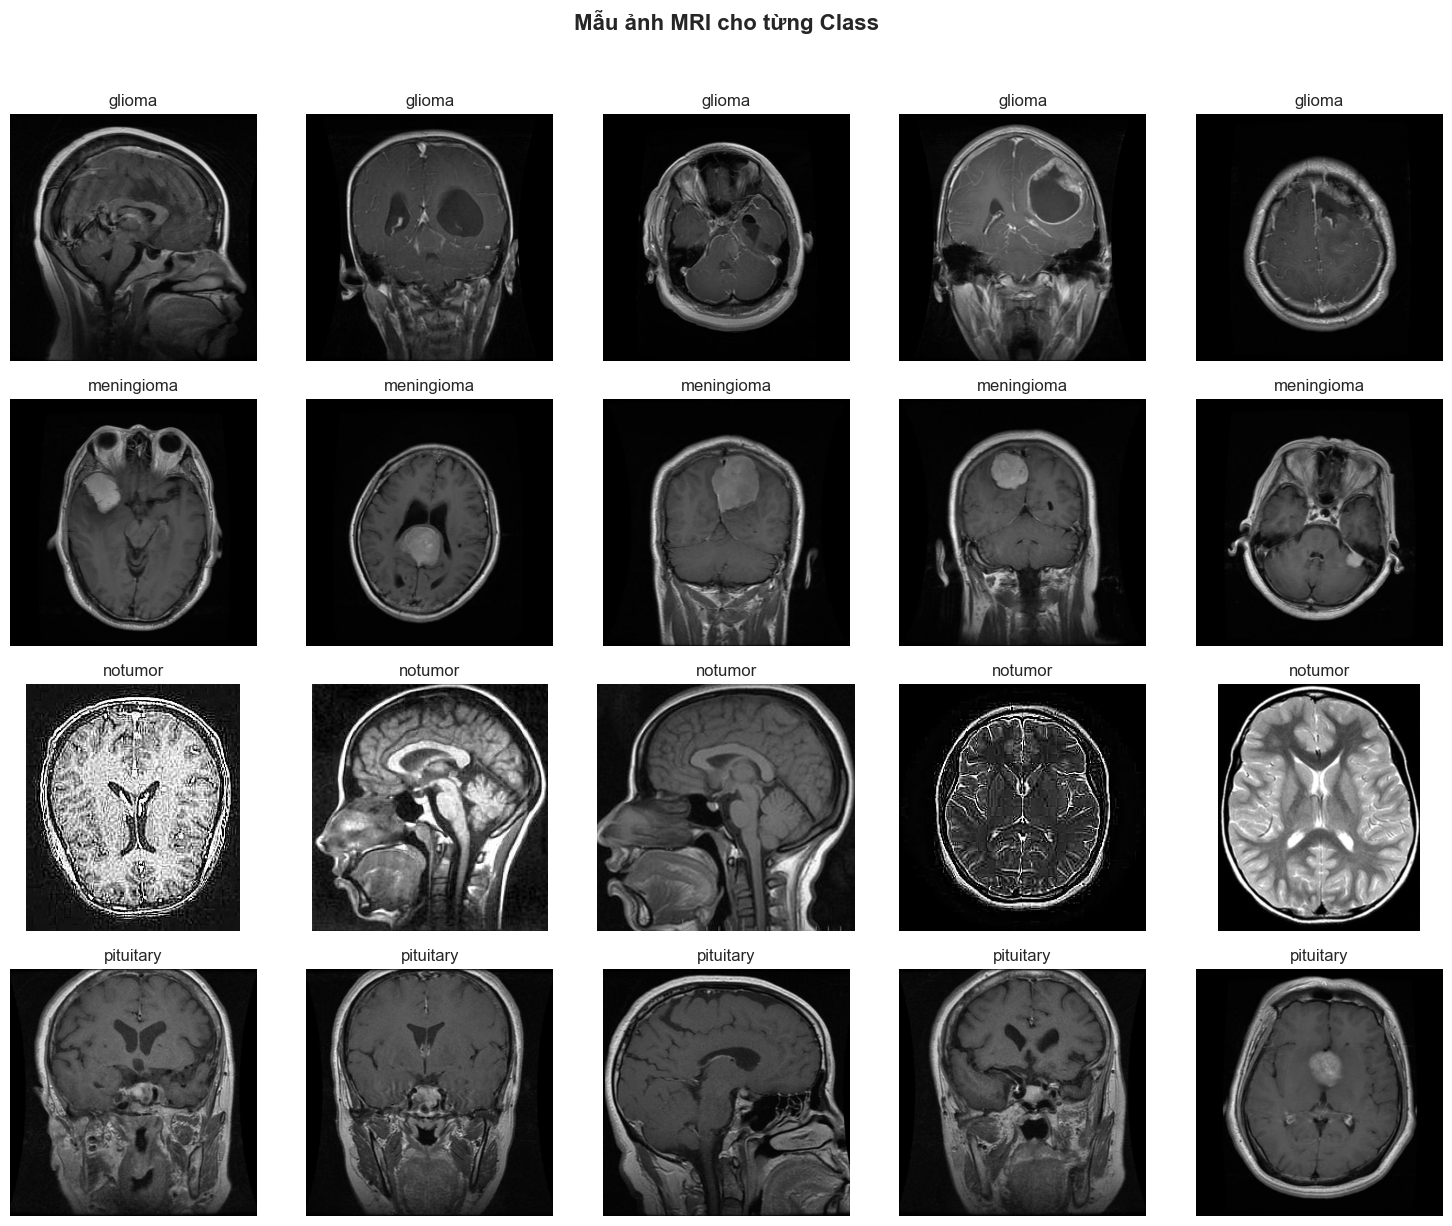

In [5]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Mẫu ảnh MRI cho từng Class', fontsize=16, fontweight='bold', y=1.02)

for i, cls in enumerate(CLASSES):
    cls_imgs = df[df['Label'] == cls]['Path'].values
    np.random.seed(42)
    if len(cls_imgs) > 0:
        selected_imgs = np.random.choice(cls_imgs, min(5, len(cls_imgs)), replace=False)
        for j, img_path in enumerate(selected_imgs):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].set_title(cls)
            axes[i, j].axis('off')
    else:
        for j in range(5):
            axes[i, j].axis('off')
            axes[i, j].set_title(f'{cls} (No Data)')

plt.tight_layout()
plt.show()

## 4. Phân tích Cường độ Pixel (Pixel Intensity Analysis)
Biểu đồ phân bố màu sắc (Histogram) giúp phát hiện xem hình ảnh có quá tối/quá sáng hay không, từ đó gợi ý các phương pháp tiền xử lý như Histogram Equalization.

In [ ]:
plt.figure(figsize=(12, 6))
colors = ['red', 'green', 'blue', 'purple']

for i, cls in enumerate(CLASSES):
    cls_imgs = df[df['Label'] == cls]['Path'].values
    if len(cls_imgs) > 0:
        # Lấy mẫu 20 ảnh để vẽ chung 1 đường phân bố KDE
        selected = np.random.choice(cls_imgs, min(20, len(cls_imgs)), replace=False)
        pixel_values = []
        for path in selected:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                pixel_values.extend(img.flatten())
        
        if len(pixel_values) > 0:
            sns.kdeplot(pixel_values, label=cls, color=colors[i], alpha=0.7)

plt.title('KDE Phân bố cường độ Pixel (Grayscale) theo các Class', fontsize=14)
plt.xlabel('Pixel Intensity (0 - 255)')
plt.ylabel('Density')
plt.legend()
plt.show()